# Don't Drop Out Of Numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Remember, its very important when working in `numpy` that you do not "drop out of `numpy`" that is change your data into regular lists.

In [6]:
type(1.4)

float

In [2]:
type([1,2])

list

In [3]:
type(np.array([1,2]))

numpy.ndarray

The most common way to "drop out of `numpy`" is to use a list comprehension on a `numpy` array.

In [7]:
l = []
for v in range(10):
    l.append(1 if v%2==0 else 0)
l

[1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

In [8]:
[1 if v%2==0 else 0 for v in range(10)] # list comprehension

[1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

In [9]:
type([v for v in np.array([1,2])])

list

#### `numpy` vs `math`

Python has a `math` library in addition to `numpy`. The main difference is that `numpy` works on vectors, whereas `math` works on scalar values.

In [12]:
import math

We will need cosine and sine functions to define our true function. As we will be performing vector calculations, we will need to use the `numpy` trigonometric functions as opposed to the `math` trigonometric functions.

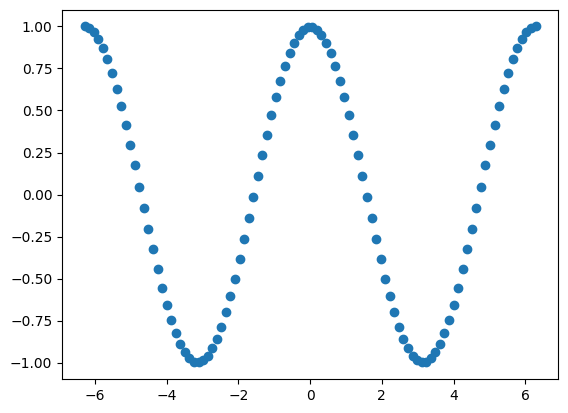

In [10]:
vv = np.linspace(-2*np.pi,2*np.pi,100)
plt.scatter(vv, np.cos(vv)) # this is a vectorized operation

In [16]:
try:
    math.cos(vv)
except TypeError as e:
    print("ERROR:", e)

ERROR: only length-1 arrays can be converted to Python scalars


In [17]:
vv[:20]

array([-6.28318531, -6.15625227, -6.02931923, -5.9023862 , -5.77545316,
       -5.64852012, -5.52158709, -5.39465405, -5.26772102, -5.14078798,
       -5.01385494, -4.88692191, -4.75998887, -4.63305583, -4.5061228 ,
       -4.37918976, -4.25225672, -4.12532369, -3.99839065, -3.87145761])

We could perform a list comprehension using the `math` function.

In [18]:
cos_vv = [math.cos(v) for v in vv] # not vectorized, list comprehension where math.cos is applied to each element of vv

In [19]:
cos_vv[:20]

[1.0,
 0.9919548128307952,
 0.9679487013963562,
 0.9283679330160723,
 0.8738493770697849,
 0.8052702575310583,
 0.7237340381050701,
 0.6305526670845221,
 0.5272254676105024,
 0.41541501300188605,
 0.29692037532827487,
 0.17364817766692997,
 0.04758191582374238,
 -0.07924995685678879,
 -0.2048066680651914,
 -0.3270679633174219,
 -0.44406661260577396,
 -0.5539200638661105,
 -0.6548607339452852,
 -0.7452644496757548]

The issue is time.

In [20]:
cos_vv_np = np.cos(vv)
cos_vv_np[:20]

array([ 1.        ,  0.99195481,  0.9679487 ,  0.92836793,  0.87384938,
        0.80527026,  0.72373404,  0.63055267,  0.52722547,  0.41541501,
        0.29692038,  0.17364818,  0.04758192, -0.07924996, -0.20480667,
       -0.32706796, -0.44406661, -0.55392006, -0.65486073, -0.74526445])

In [21]:
%%timeit
np.cos(vv)

455 ns ± 3.05 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [22]:
%%timeit
[math.cos(v) for v in vv]

4.62 μs ± 16.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


This difference only increases for larger $n$.

In [23]:
%%timeit 
np.cos(np.linspace(1,1000,10000))

36.9 μs ± 1.5 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [24]:
%%timeit 
[math.cos(v) for v in np.linspace(1,1000,10000)]

448 μs ± 1.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
